<h1>L1-based models for Sparse Signals</h1>

The present example compares three l1-based regression models on a synthetic signal obtained from sparse and correlated features that are further corrupted with additive Gaussian noise:

a Lasso;

an Automatic Relevance Determination - ARD;

an Elastic-Net.

It is known that the Lasso estimates turn to be close to the model selection estimates when the data dimensions grow, given that the irrelevant variables are not too correlated with the relevant ones. In the presence of correlated features, Lasso itself cannot select the correct sparsity pattern [1].

Here we compare the performance of the three models in terms of the R^2
 score, the fitting time and the sparsity of the estimated coefficients when compared with the ground-truth.

<h1>Generate synthetic dataset</h1>
<p>We generate a dataset where the number of samples is lower than the total number of features. This leads to an underdetermined system, i.e. the solution is not unique, and thus we cannot apply an Ordinary Least Squares by itself. Regularization introduces a penalty term to the objective function, which modifies the optimization problem and can help alleviate the underdetermined nature of the system.</p>

<b>The target y is a linear combination with alternating signs of sinusoidal signals. Only the 10 lowest out of the 100 frequencies in X are used to generate y, while the rest of the features are not informative. This results in a high dimensional sparse feature space, where some degree of l1-penalization is necessary.</b>

In [1]:
import numpy as np

rng = np.random.RandomState(0)
n_samples, n_features, n_informative = 50, 100, 10
time_step = np.linspace(-2, 2, n_samples)
freqs = 2 * np.pi * np.sort(rng.rand(n_features)) / 0.01
X = np.zeros((n_samples, n_features))

for i in range(n_features):
    X[:, i] = np.sin(freqs[i] * time_step)

idx = np.arange(n_features)
true_coef = (-1) ** idx * np.exp(-idx / 10)
true_coef[n_informative:] = 0  # sparsify coef
y = np.dot(X, true_coef)

In [2]:
freqs[:n_informative]

array([ 2.9502547 , 11.8059798 , 12.63394388, 12.70359377, 24.62241605,
       37.84077985, 40.30506066, 44.63327171, 54.74495357, 59.02456369])

In [3]:
for i in range(n_features):
    X[:, i] = np.sin(freqs[i] * time_step + 2 * (rng.random_sample() - 0.5))
    X[:, i] += 0.2 * rng.normal(0, 1, n_samples)

y += 0.2 * rng.normal(0, 1, n_samples)

In [4]:
import matplotlib.pyplot as plt
def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    if tight_layout:
        plt.tight_layout()
    plt.savefig(f"{fig_id}.{fig_extension}", format=fig_extension, dpi=resolution)

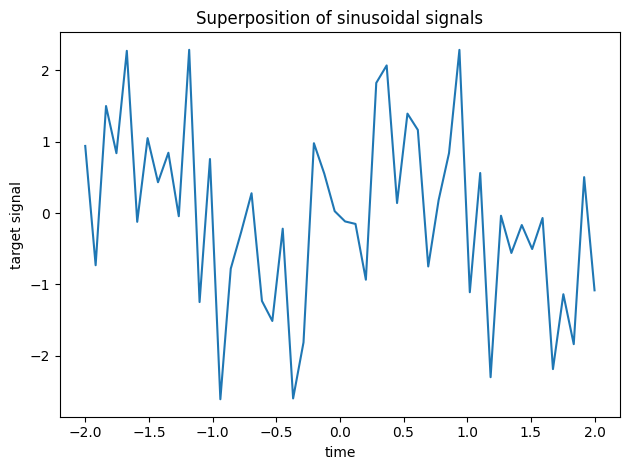

In [6]:

plt.plot(time_step, y)
plt.ylabel("target signal")
plt.xlabel("time")
_ = plt.title("Superposition of sinusoidal signals")
save_fig("lasso_signal_plot")    

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, shuffle=False)

In [8]:
from time import time

from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score

t0 = time()
lasso = Lasso(alpha=0.14).fit(X_train, y_train)
print(f"Lasso fit done in {(time() - t0):.3f}s")

y_pred_lasso = lasso.predict(X_test)
r2_score_lasso = r2_score(y_test, y_pred_lasso)
print(f"Lasso r^2 on test data : {r2_score_lasso:.3f}")

Lasso fit done in 0.010s
Lasso r^2 on test data : 0.480
